In [1]:
import numpy as np
import statsmodels.api as sm
from unifres import fresiduals, ffplot, fredplot

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [5]:
bikedata = pd.read_csv("/Users/linzw/Desktop/TexasResearch/JSS/Datasets/hour.csv")
bikedata.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [7]:
# Our analysis focuses on the 2012 data
bikedata = bikedata.loc[bikedata["yr"] == 1].copy()

# Create a new variable called 'winter'
bikedata["winter"] = np.where(bikedata["season"] == 1, 1, 0)

bikedata[["yr", "season", "winter"]].head()

,yr,season,winter
8645,1,1,1
8646,1,1,1
8647,1,1,1
8648,1,1,1
8649,1,1,1


In [9]:
model1 = smf.glm(
    formula="cnt ~ winter + hr + workingday + weathersit + temp + hum + windspeed",
    data=bikedata,
    family=sm.families.Poisson()
).fit()

print(model1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    cnt   No. Observations:                 8734
Model:                            GLM   Df Residuals:                     8726
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.6427e+05
Date:                Thu, 19 Mar 2026   Deviance:                   1.0707e+06
Time:                        23:22:23   Pearson chi2:                 1.19e+06
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.8481      0.005    996.903      0.0

<Axes: xlabel='hr', ylabel='Residual Density'>

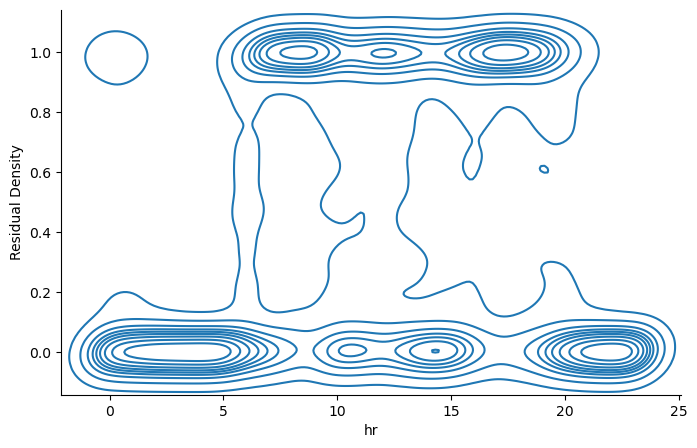

In [11]:
# Functional residual plots
fredplot(model1, bikedata["hr"])


<Axes: xlabel='workingday', ylabel='Residual Density'>

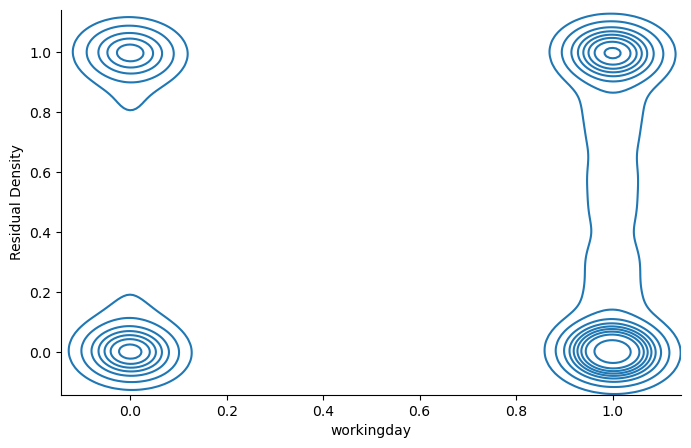

In [13]:
fredplot(model1, bikedata["workingday"])


<Axes: xlabel='temp', ylabel='Residual Density'>

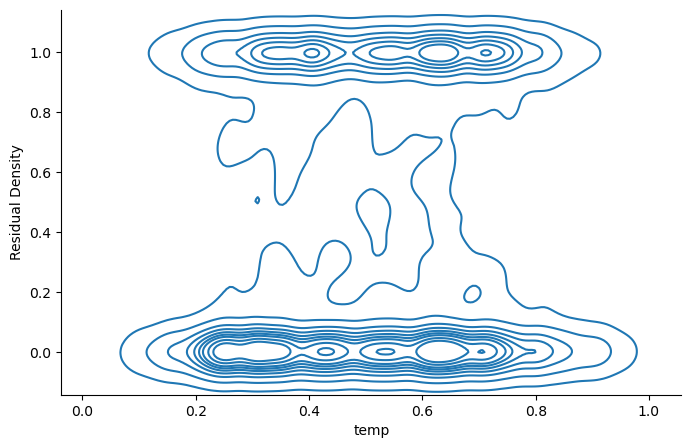

In [15]:
fredplot(model1, bikedata["temp"])


<Axes: xlabel='hum', ylabel='Residual Density'>

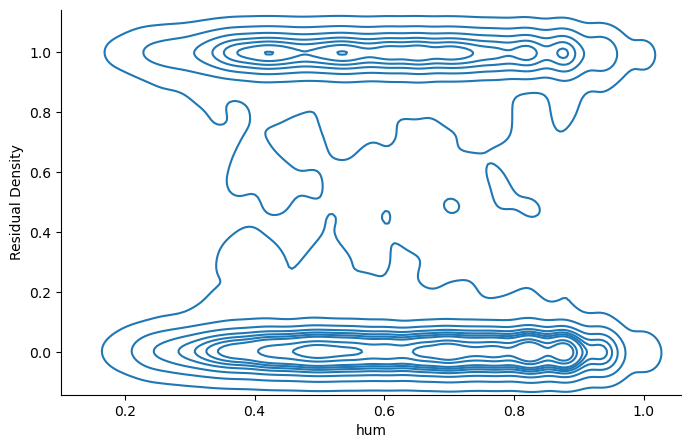

In [16]:
fredplot(model1, bikedata["hum"])


<Axes: xlabel='windspeed', ylabel='Residual Density'>

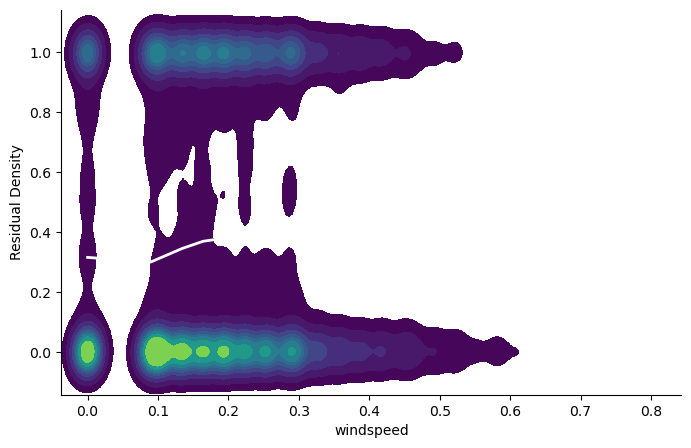

In [31]:
fredplot(model1, bikedata["windspeed"],type="kde",
         lowess=True, frac=0.5,
         fill=True, cmap='viridis')

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2148: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2148: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


<Axes: title={'center': 'Function-Function Plot'}, xlabel='t', ylabel='Average Functional Residual'>

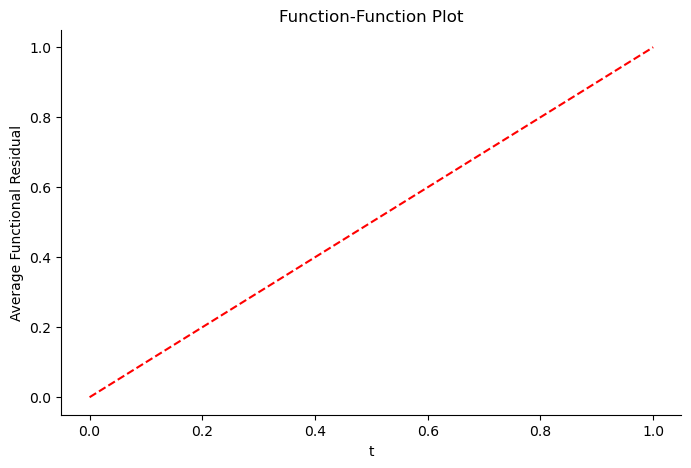

In [35]:
# Global functional-form diagnostic plot
ffplot(model1,color='steelblue', linewidth=2)